# Class Imbalance Visualization

This notebook visualizes label imbalance from `all_timelines_merged.csv` using the `_category` fields.

- A row is counted as **present** for an element when the corresponding `_category` cell has non-empty text.
- Total rows are shown as a dotted reference line in each plot.

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

CSV_PATH = "all_timelines_merged.csv"
CATEGORY_COLUMNS = [
    "adaptive-state_A_category",
    "adaptive-state_B-S_category",
    "adaptive-state_B-O_category",
    "adaptive-state_C-O_category",
    "adaptive-state_C-S_category",
    "adaptive-state_D_category",
    "maladaptive-state_A_category",
    "maladaptive-state_B-S_category",
    "maladaptive-state_B-O_category",
    "maladaptive-state_C-S_category",
    "maladaptive-state_C-O_category",
    "maladaptive-state_D_category",
]

df = pd.read_csv(CSV_PATH)
missing = [c for c in CATEGORY_COLUMNS if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected category columns: {missing}")

print(f"Rows: {len(df)}")
print(f"Using {len(CATEGORY_COLUMNS)} category columns")

Rows: 373
Using 12 category columns


In [27]:
def normalize_category(series: pd.Series) -> pd.Series:
    s = series.fillna("").astype(str).str.strip()
    return s.mask(s == "", "ABSENT")

counts_frames = []
presence_rows = []

for col in CATEGORY_COLUMNS:
    normalized = normalize_category(df[col])
    vc = normalized.value_counts(dropna=False).rename_axis("category").reset_index(name="count")
    vc["element"] = col.replace("_category", "")
    counts_frames.append(vc)

    absent_count = int((normalized == "ABSENT").sum())
    present_count = len(normalized) - absent_count
    presence_rows.append({
        "element": col.replace("_category", ""),
        "present": present_count,
        "absent": absent_count,
        "present_rate": present_count / len(normalized),
    })

counts_df = pd.concat(counts_frames, ignore_index=True)
presence_df = pd.DataFrame(presence_rows).sort_values("present_rate", ascending=False)

presence_df[["element", "present", "absent", "present_rate"]]

,element,present,absent,present_rate
6,maladaptive-state_A,161,212,0.431635
9,maladaptive-state_C-S,135,238,0.361930
2,adaptive-state_B-O,125,248,0.335121
5,adaptive-state_D,118,255,0.316354
10,maladaptive-state_C-O,114,259,0.305630
11,maladaptive-state_D,110,263,0.294906
1,adaptive-state_B-S,84,289,0.225201
7,maladaptive-state_B-S,59,314,0.158177
4,adaptive-state_C-S,52,321,0.139410
3,adaptive-state_C-O,50,323,0.134048


## Plot 1: Presence count per element

Shows how many rows contain each element, with a dotted line marking total rows.

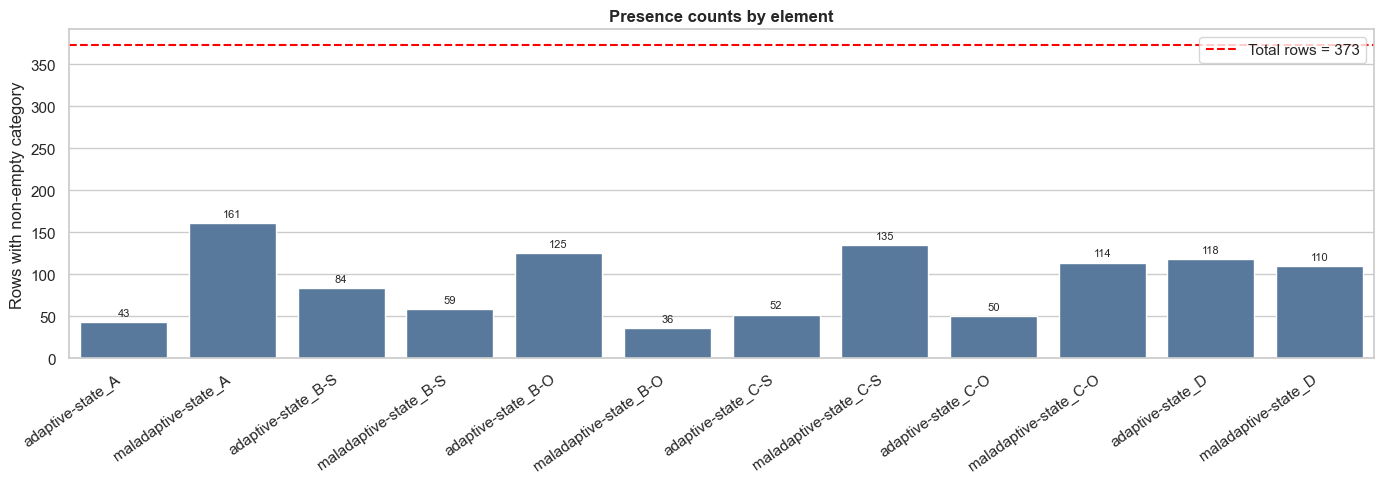

In [28]:
element_order = [
    "adaptive-state_A", "maladaptive-state_A",
    "adaptive-state_B-S", "maladaptive-state_B-S",
    "adaptive-state_B-O", "maladaptive-state_B-O",
    "adaptive-state_C-S", "maladaptive-state_C-S",
    "adaptive-state_C-O", "maladaptive-state_C-O",
    "adaptive-state_D", "maladaptive-state_D",
]

plot_presence = presence_df.copy()
plot_presence["element"] = pd.Categorical(plot_presence["element"], categories=element_order, ordered=True)
plot_presence = plot_presence.sort_values("element")
total_rows = len(df)

plt.figure(figsize=(14, 5))
ax = sns.barplot(data=plot_presence, x="element", y="present", color="#4C78A8")
ax.axhline(total_rows, color="red", linestyle="--", linewidth=1.5, label=f"Total rows = {total_rows}")
ax.set_title("Presence counts by element", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Rows with non-empty category")
ax.legend(loc="upper right")

for patch in ax.patches:
    value = int(round(patch.get_height()))
    ax.annotate(
        f"{value}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=8,
        xytext=(0, 3),
        textcoords="offset points",
    )

plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## Plot 2: Category distribution among present rows

Faceted bars show imbalance across category IDs for rows where the element exists. All subplots share the same y-axis scale for direct visual comparison.

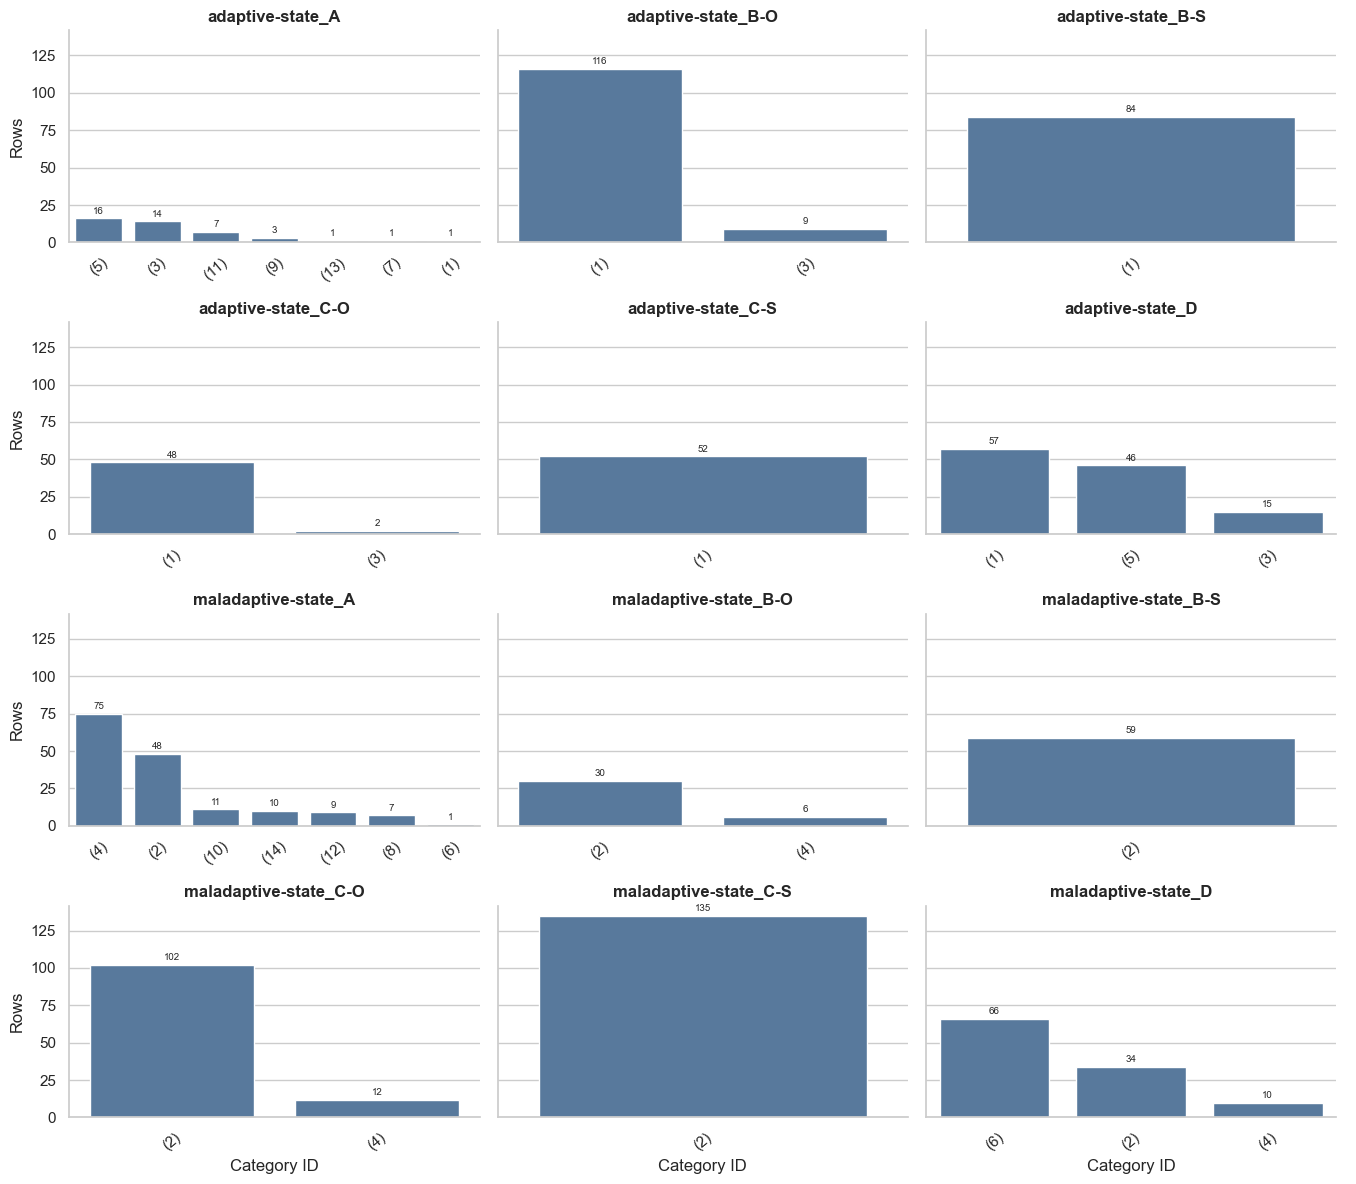

In [ ]:
plot_counts = counts_df.copy()

# Drop ABSENT to focus on category imbalance among present examples
plot_counts = plot_counts[plot_counts["category"] != "ABSENT"].copy()

# Keep compact labels only: numeric prefix like (1), (2), ...
prefix = plot_counts["category"].str.extract(r"^\((\d+)\)", expand=False)
plot_counts["category_short"] = "(" + prefix.fillna("?") + ")"

# Sort categories inside each facet by count descending
plot_counts = plot_counts.sort_values(["element", "count"], ascending=[True, False])

g = sns.catplot(
    data=plot_counts,
    kind="bar",
    x="category_short",
    y="count",
    col="element",
    col_wrap=3,
    sharex=False,
    sharey=True,
    height=3,
    aspect=1.5,
    color="#4C78A8",
)

g.set_axis_labels("Category ID", "Rows")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=40)
    ax.set_title(ax.get_title(), fontweight="bold")
    for patch in ax.patches:
        value = int(round(patch.get_height()))
        ax.annotate(
            f"{value}",
            (patch.get_x() + patch.get_width() / 2, patch.get_height()),
            ha="center",
            va="bottom",
            fontsize=7,
            xytext=(0, 2),
            textcoords="offset points",
        )

plt.tight_layout()
plt.show()